# 1. Base Setup

## 1.1 Install packages

In [1]:
!pip install kagglehub
!pip install xgboost

## 1.2 Load all needed imports

In [2]:
from pathlib import Path

import pandas as pd
import kagglehub
from kagglehub import KaggleDatasetAdapter
import numpy as np
import matplotlib.pyplot as plt

from dateutil.relativedelta import relativedelta

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, log_loss, confusion_matrix
from sklearn.calibration import calibration_curve
from sklearn.model_selection import RandomizedSearchCV, PredefinedSplit, GridSearchCV

from scipy.stats import randint, uniform


/Users/anton/.pyenv/versions/3.10.6/envs/cf_copilot/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 2. Load the data

In [3]:
def load_cashflow_data(csv_name: str = "dataset.csv") -> pd.DataFrame:
    # 1) Look for local file first: ../raw_data/dataset.csv
    base_dir = Path.cwd().parent          # one level up from notebook
    raw_data_dir = base_dir / "raw_data"
    raw_data_dir.mkdir(parents=True, exist_ok=True)
    local_path = raw_data_dir / csv_name

    if local_path.is_file():
        print(f"Loading local file: {local_path}")
        return pd.read_csv(local_path)

    # 2) If not found, download from Kaggle once via kagglehub
    print("Local file not found, downloading from Kaggle via kagglehub...")
    df = kagglehub.dataset_load(
        KaggleDatasetAdapter.PANDAS,
        "pradumn203/payment-date-prediction-for-invoices-dataset",
        "dataset.csv",  # main CSV name on Kaggle
    )

    # Save for future offline use
    df.to_csv(local_path, index=False)
    print(f"Saved local copy to {local_path}")

    return df

df = load_cashflow_data()

Loading local file: /Users/anton/code/DERNTOAN/cf_copilot/raw_data/dataset.csv


# 3. EDA

## 3.1 General Informatoin

In [4]:
df.head()

,business_code,cust_number,name_customer,clear_date,buisness_year,doc_id,posting_date,document_create_date,document_create_date.1,due_in_date,invoice_currency,document type,posting_id,area_business,total_open_amount,baseline_create_date,cust_payment_terms,invoice_id,isOpen
0,U001,0200769623,WAL-MAR corp,2020-02-11 00:00:00,2020.0,1.930438e+09,2020-01-26,20200125,20200126,20200210.0,USD,RV,1.0,NaN,54273.28,20200126.0,NAH4,1.930438e+09,0
1,U001,0200980828,BEN E,2019-08-08 00:00:00,2019.0,1.929646e+09,2019-07-22,20190722,20190722,20190811.0,USD,RV,1.0,NaN,79656.60,20190722.0,NAD1,1.929646e+09,0
2,U001,0200792734,MDV/ trust,2019-12-30 00:00:00,2019.0,1.929874e+09,2019-09-14,20190914,20190914,20190929.0,USD,RV,1.0,NaN,2253.86,20190914.0,NAA8,1.929874e+09,0
3,CA02,0140105686,SYSC llc,NaN,2020.0,2.960623e+09,2020-03-30,20200330,20200330,20200410.0,CAD,RV,1.0,NaN,3299.70,20200331.0,CA10,2.960623e+09,1
4,U001,0200769623,WAL-MAR foundation,2019-11-25 00:00:00,2019.0,1.930148e+09,2019-11-13,20191113,20191113,20191128.0,USD,RV,1.0,NaN,33133.29,20191113.0,NAH4,1.930148e+09,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   business_code           50000 non-null  object 
 1   cust_number             50000 non-null  object 
 2   name_customer           50000 non-null  object 
 3   clear_date              40000 non-null  object 
 4   buisness_year           50000 non-null  float64
 5   doc_id                  50000 non-null  float64
 6   posting_date            50000 non-null  object 
 7   document_create_date    50000 non-null  int64  
 8   document_create_date.1  50000 non-null  int64  
 9   due_in_date             50000 non-null  float64
 10  invoice_currency        50000 non-null  object 
 11  document type           50000 non-null  object 
 12  posting_id              50000 non-null  float64
 13  area_business           0 non-null      float64
 14  total_open_amount       50000 non-null

In [6]:
df.shape

(50000, 19)

## 3.2 Non-Null Values

In [7]:
print(df.isnull().sum())

business_code                 0
cust_number                   0
name_customer                 0
clear_date                10000
buisness_year                 0
doc_id                        0
posting_date                  0
document_create_date          0
document_create_date.1        0
due_in_date                   0
invoice_currency              0
document type                 0
posting_id                    0
area_business             50000
total_open_amount             0
baseline_create_date          0
cust_payment_terms            0
invoice_id                    6
isOpen                        0
dtype: int64


In [8]:
print(df.isnull().mean().round(4) * 100)

business_code               0.00
cust_number                 0.00
name_customer               0.00
clear_date                 20.00
buisness_year               0.00
doc_id                      0.00
posting_date                0.00
document_create_date        0.00
document_create_date.1      0.00
due_in_date                 0.00
invoice_currency            0.00
document type               0.00
posting_id                  0.00
area_business             100.00
total_open_amount           0.00
baseline_create_date        0.00
cust_payment_terms          0.00
invoice_id                  0.01
isOpen                      0.00
dtype: float64


# 4. Data Cleaning

## 4.1 Drop duplicates and null-values

### 4.1.1 Drop null-targets

In [9]:
invoices = df.copy().dropna(subset=["clear_date"])

### 4.1.2 Drop duplicates

In [10]:
# TODO


### 4.1.3 Drop unnecessary columns

In [11]:
invoices = invoices[['cust_number','buisness_year','due_in_date', 'invoice_currency', 'document type', 'total_open_amount','baseline_create_date', 'cust_payment_terms', 'clear_date']]

## 4.2 Clean data

### 4.2.1 Rename columns

In [12]:
invoices.rename(columns={'buisness_year': 'business_year', 'clear_date': 'invoice_paid', 'document type': 'document_type', 'baseline_create_date': 'invoice_sent'}, inplace=True)
invoices.head()

,cust_number,business_year,due_in_date,invoice_currency,document_type,total_open_amount,invoice_sent,cust_payment_terms,invoice_paid
0,0200769623,2020.0,20200210.0,USD,RV,54273.28,20200126.0,NAH4,2020-02-11 00:00:00
1,0200980828,2019.0,20190811.0,USD,RV,79656.60,20190722.0,NAD1,2019-08-08 00:00:00
2,0200792734,2019.0,20190929.0,USD,RV,2253.86,20190914.0,NAA8,2019-12-30 00:00:00
4,0200769623,2019.0,20191128.0,USD,RV,33133.29,20191113.0,NAH4,2019-11-25 00:00:00
5,0140106181,2019.0,20191004.0,CAD,RV,22225.84,20190924.0,CA10,2019-12-04 00:00:00


### 4.2.2 Format datetime-columns

In [13]:
invoices['business_year'] = invoices["business_year"].astype(int)
invoices['due_in_date'] = pd.to_datetime(invoices['due_in_date'].astype(int).astype(str), format="%Y%m%d" )
invoices['invoice_sent'] = pd.to_datetime(invoices['invoice_sent'].astype(int).astype(str), format="%Y%m%d")
invoices['invoice_paid'] = pd.to_datetime(invoices['invoice_paid'])
invoices.head()

,cust_number,business_year,due_in_date,invoice_currency,document_type,total_open_amount,invoice_sent,cust_payment_terms,invoice_paid
0,0200769623,2020,2020-02-10,USD,RV,54273.28,2020-01-26,NAH4,2020-02-11
1,0200980828,2019,2019-08-11,USD,RV,79656.60,2019-07-22,NAD1,2019-08-08
2,0200792734,2019,2019-09-29,USD,RV,2253.86,2019-09-14,NAA8,2019-12-30
4,0200769623,2019,2019-11-28,USD,RV,33133.29,2019-11-13,NAH4,2019-11-25
5,0140106181,2019,2019-10-04,CAD,RV,22225.84,2019-09-24,CA10,2019-12-04


## 4.3 Sort df by date

In [14]:
invoices = invoices.sort_values("invoice_sent").reset_index(drop=True)

# 5. Feature engineering

## 5.1 Use sliding window to extend data

### 5.1.1 Engineer more features based on current date

In [15]:
def engineer_features(snapshot, df_full, current_date):
    """Engineer all features for a given reference date."""

    # 1. Invoice age
    snapshot["invoice_age_days"] = (current_date - snapshot["invoice_sent"]).dt.days

    # 2. Days until due date
    snapshot["days_until_due"] = (snapshot["due_in_date"] - current_date).dt.days

    # 3. Invoice month
    snapshot["invoice_month"] = snapshot["invoice_sent"].dt.month

    # 4. Due month
    snapshot["due_month"] = snapshot["due_in_date"].dt.month

    # 5. Days past due
    snapshot["days_past_due"] = (current_date - snapshot["due_in_date"]).dt.days

    # Behaviour specific to one customer. Needs to be calculated on whole DF,
    # since we need historical data for it

    # Get all invoices that are paid before current_date
    historical = df_full[df_full["invoice_paid"] <= current_date].copy()

    # 6. Customer average payment delay
    # Calculate delay for all paid invoices
    historical["delay"] = (historical["invoice_paid"] - historical["due_in_date"]).dt.days.clip(lower=0)
    # Calculate avg delay for each customer
    avg_delay = historical.groupby("cust_number")["delay"].mean().rename("customer_avg_delay")

    # 7. Customer late payment ratio
    # Caluclate boolean field, whether or not an invoice was paid late
    historical["is_late"] = (historical["invoice_paid"] > historical["due_in_date"]).astype(int)
    # calculate ratio of late-payhments per customer
    late_ratio = historical.groupby("cust_number")["is_late"].mean().rename("late_payment_ratio")

    # 8. Number of previous transactions
    before_current = df_full[df_full["invoice_sent"] < current_date]
    prev_counts = before_current.groupby("cust_number").size().rename("prev_transaction_count")

    # 9. Days since last invoice
    last_invoice = (
        before_current.groupby("cust_number")["invoice_sent"]
        .max()
        .rename("last_invoice_date")
    )

    # Merge all customer-level features
    customer_features = pd.concat([avg_delay, late_ratio, prev_counts, last_invoice], axis=1)
    snapshot = snapshot.merge(customer_features, on="cust_number", how="left")

    # 10. Customer risk score
    snapshot["customer_risk_score"] = (
        0.7 * snapshot["late_payment_ratio"].fillna(0)
        + 0.3 * snapshot["customer_avg_delay"].fillna(0)
    )

    # 11. cont. Convert last invoice date to days
    snapshot["days_since_last_invoice"] = (current_date - snapshot["last_invoice_date"]).dt.days
    snapshot.drop(columns=["last_invoice_date"], inplace=True)

    # Fill NaN for new customers
    snapshot["prev_transaction_count"] = snapshot["prev_transaction_count"].fillna(0).astype(int)

    # 13. Open amount
    snapshot["open_amount"] = snapshot["total_open_amount"]

    return snapshot

### 5.1.2 Create more data with sliding window

In [16]:
all_snapshots = []

start_date = invoices["invoice_sent"].min()

# We need to make sure to have 6 weeks at the end of the last sliding window
# to be able to create y_train
end_date = invoices["invoice_paid"].max() - pd.Timedelta(weeks=6)
# Move one week forward after each calculation
stride = pd.Timedelta(weeks=1)

current = start_date
while current <= end_date:
    # All invoices that have been sent out before current and have not been paid
    # yet
    snapshot = invoices[
        (invoices["invoice_sent"] <= current) &
        (invoices["invoice_paid"] > current)
    ].copy()

    # Engineer aditional features for the sliding window
    snapshot = engineer_features(snapshot, invoices, current)

    # Engineer target (in which bucket did the invoice land)
    snapshot["reference_date"] = current
    snapshot["days_to_payment"] = (snapshot["invoice_paid"] - current).dt.days
    snapshot["week_bucket"] = np.ceil(snapshot["days_to_payment"] / 7).astype(int)
    snapshot["week_bucket"] = snapshot["week_bucket"].clip(lower=1)
    snapshot.loc[snapshot["week_bucket"] > 6, "week_bucket"] = 7

    all_snapshots.append(snapshot)
    current += stride

big_df = pd.concat(all_snapshots, ignore_index=True)
print(f"Original rows: {len(invoices)}")
print(f"Augmented rows: {len(big_df)}")
print(big_df["week_bucket"].value_counts().sort_index())

Original rows: 40000
Augmented rows: 100332
week_bucket
1    39666
2    33786
3    10608
4     4095
5     3241
6     2241
7     6695
Name: count, dtype: int64


In [17]:
big_df.head()

,cust_number,business_year,due_in_date,invoice_currency,document_type,total_open_amount,invoice_sent,cust_payment_terms,invoice_paid,invoice_age_days,...,days_past_due,customer_avg_delay,late_payment_ratio,prev_transaction_count,customer_risk_score,days_since_last_invoice,open_amount,reference_date,days_to_payment,week_bucket
0,0140104249,2019,2018-12-24,CAD,RV,155010.63,2018-12-14,CA10,2019-01-23,0,...,-10,NaN,NaN,0,0.0,NaN,155010.63,2018-12-14,40,6
1,0200706844,2019,2018-12-29,USD,RV,576.88,2018-12-14,NAA8,2019-02-19,0,...,-15,NaN,NaN,0,0.0,NaN,576.88,2018-12-14,67,7
2,0140104249,2019,2018-12-24,CAD,RV,155010.63,2018-12-14,CA10,2019-01-23,7,...,-3,NaN,NaN,1,0.0,7.0,155010.63,2018-12-21,33,5
3,0200706844,2019,2018-12-29,USD,RV,576.88,2018-12-14,NAA8,2019-02-19,7,...,-8,NaN,NaN,1,0.0,7.0,576.88,2018-12-21,60,7
4,0140104249,2019,2018-12-24,CAD,RV,155010.63,2018-12-14,CA10,2019-01-23,14,...,4,NaN,NaN,1,0.0,14.0,155010.63,2018-12-28,26,4


# 6. Cleaning and prepocessing the big DF

## 6.1 Quick EDA on the bigger DF

In [18]:
print(big_df.isnull().sum())

cust_number                   0
business_year                 0
due_in_date                   0
invoice_currency              0
document_type                 0
total_open_amount             0
invoice_sent                  0
cust_payment_terms            0
invoice_paid                  0
invoice_age_days              0
days_until_due                0
invoice_month                 0
due_month                     0
days_past_due                 0
customer_avg_delay         6758
late_payment_ratio         6758
prev_transaction_count        0
customer_risk_score           0
days_since_last_invoice     245
open_amount                   0
reference_date                0
days_to_payment               0
week_bucket                   0
dtype: int64


In [19]:
print(big_df.isnull().mean().round(4) * 100)

cust_number                0.00
business_year              0.00
due_in_date                0.00
invoice_currency           0.00
document_type              0.00
total_open_amount          0.00
invoice_sent               0.00
cust_payment_terms         0.00
invoice_paid               0.00
invoice_age_days           0.00
days_until_due             0.00
invoice_month              0.00
due_month                  0.00
days_past_due              0.00
customer_avg_delay         6.74
late_payment_ratio         6.74
prev_transaction_count     0.00
customer_risk_score        0.00
days_since_last_invoice    0.24
open_amount                0.00
reference_date             0.00
days_to_payment            0.00
week_bucket                0.00
dtype: float64


## 6.2 Cleaning and preprocessing

In [20]:
def preprocess(df):
    # make sure there are no empty targets
    df = df.dropna(subset=["week_bucket"])

    # Fill NaN for customers with no history
    df["customer_avg_delay"] = df["customer_avg_delay"].fillna(0)
    df["late_payment_ratio"] = df["late_payment_ratio"].fillna(0)
    df["days_since_last_invoice"] = df["days_since_last_invoice"].fillna(-1)  # flag as unknown

    # Define feature columns (exclude identifiers, dates, target, leaky columns)
    drop_cols = [
        "cust_number", "due_in_date", "invoice_sent", "reference_date", "week_bucket", "days_to_payment"
    ]
    feature_cols = [c for c in df.columns if c not in drop_cols]

    X = df[feature_cols]
    y = df["week_bucket"] - 1

    return X, y

# 7. Prepare training

## 7.1 Train-test-split

In [21]:
# Since we are working with time-series, we can't use the random split but need
# to split the data at a certain date

# Make sure data is sorted correctly
big_df = big_df.sort_values("invoice_sent").reset_index(drop=True)

# Use the last ~20% of time as test
cutoff_date = big_df["invoice_sent"].quantile(0.8)

train_df = big_df[big_df["reference_date"] <= cutoff_date]
test_df = big_df[big_df["reference_date"] > cutoff_date]

# Create train and test datasets
X_train, y_train = preprocess(train_df)
X_test, y_test = preprocess(test_df)

# 8. Base Model

## 8.1 Pipelines

### 8.1.1 Preprocessing pipeline

In [22]:
# Define column groups
numeric_features = [
    "invoice_age_days", "days_until_due", "days_past_due",
    "invoice_month", "due_month",
    "customer_avg_delay", "late_payment_ratio",
    "prev_transaction_count", "customer_risk_score",
    "days_since_last_invoice", "open_amount",
]

categorical_features = [
    "invoice_currency", "document_type", 'cust_payment_terms'
]

# Numeric: just fill NaN
numeric_transformer = SimpleImputer(strategy="median")

# Categorical: fill NaN then encode as integers
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value=-1)),
    ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
])

# Combine
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop",  # drop anything not listed above
)

preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


### 8.1.2 Model pipeline

In [23]:
classifier = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features="sqrt",
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

classifier

,n_estimators,300
,criterion,'gini'
,max_depth,8
,min_samples_split,20
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### 8.1.3 Full pipeline

In [24]:
base_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", classifier),
])

base_pipeline

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## 8.2 Train the model

In [25]:
base_pipeline.fit(X_train, y_train)

base_probas = base_pipeline.predict_proba(X_test)
base_preds = base_pipeline.predict(X_test)

# 9. Evaluation of the model

In [26]:
def evaluate_model(probas, preds):
    print(f"Log loss: {log_loss(y_test, probas):.4f}")
    print(classification_report(y_test, preds))
    print(confusion_matrix(y_test, preds))
    return None

In [27]:
def show_calibration_curves(probas, pipeline):
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    for i, bucket in enumerate(pipeline.classes_):
        ax = axes.flat[i]
        y_binary = (y_test == bucket).astype(int)
        prob_true, prob_pred = calibration_curve(y_binary, probas[:, i], n_bins=10)
        ax.plot(prob_pred, prob_true, marker="o")
        ax.plot([0, 1], [0, 1], "k--")
        ax.set_title(f"Bucket {bucket}")
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")
    plt.tight_layout()
    plt.show()

In [28]:
evaluate_model(base_probas, base_preds)

Log loss: 0.9580
              precision    recall  f1-score   support

           0       0.86      0.83      0.85      9831
           1       0.81      0.68      0.74      7731
           2       0.54      0.46      0.50      2210
           3       0.21      0.64      0.31       798
           4       0.45      0.41      0.43       562
           5       0.32      0.35      0.33       316
           6       0.48      0.65      0.55       788

    accuracy                           0.71     22236
   macro avg       0.52      0.57      0.53     22236
weighted avg       0.76      0.71      0.73     22236

[[8179  712  159  522   16   10  233]
 [1109 5225  615  553   66   14  149]
 [ 123  458 1025  442   64   29   69]
 [  37   48   56  510   65   40   42]
 [  14   18   16  186  228   74   26]
 [  13    2    5  113   35  110   38]
 [  34   21    5  121   31   65  511]]


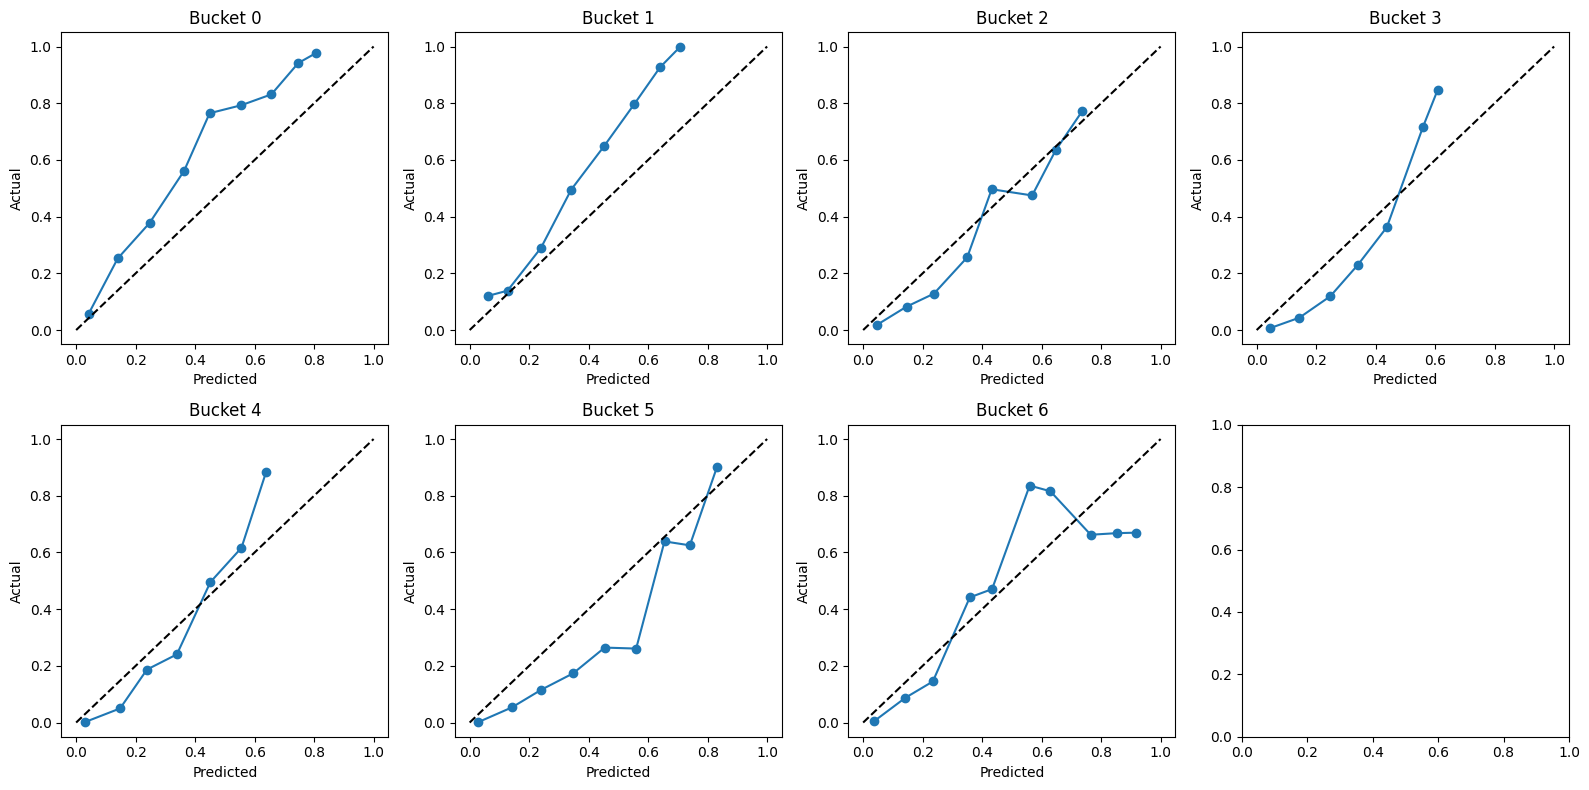

In [29]:
show_calibration_curves(base_probas, base_pipeline)

## 9.2 Simulate how the model would have performed at any point in time

In [30]:
def simulate_past_performance(pipeline):
    reference_dates = big_df["reference_date"].sort_values().unique()
    cutoffs = np.percentile(reference_dates.astype(int), [40, 50, 60, 70, 80])
    cutoffs = pd.to_datetime(cutoffs)

    scores = []
    for cutoff in cutoffs:
        train_df = big_df[big_df["reference_date"] <= cutoff]
        test_df = big_df[
            (big_df["reference_date"] > cutoff) &
            (big_df["reference_date"] <= cutoff + pd.Timedelta(weeks=6))
        ]

        if len(test_df) == 0:
            continue

        X_train, y_train = preprocess(train_df)
        X_test, y_test = preprocess(test_df)

        pipeline.fit(X_train, y_train)
        probas = pipeline.predict_proba(X_test)
        score = log_loss(y_test, probas, labels=pipeline.classes_)
        scores.append(score)
        print(f"Cutoff {cutoff.date()} -> log_loss: {score:.4f}")

    print(f"\nAverage: {np.mean(scores):.4f} (std: {np.std(scores):.4f})")

In [31]:
simulate_past_performance(base_pipeline)

Cutoff 2019-06-25 -> log_loss: 0.9492
Cutoff 2019-08-12 -> log_loss: 0.9767
Cutoff 2019-09-29 -> log_loss: 1.0559
Cutoff 2019-11-17 -> log_loss: 0.9216
Cutoff 2020-01-04 -> log_loss: 0.8857

Average: 0.9578 (std: 0.0576)


# 10. Tune the model

In [32]:
cutoff_date = big_df["reference_date"].quantile(0.8)
test_fold = np.where(big_df["reference_date"] <= cutoff_date, -1, 0)
ps = PredefinedSplit(test_fold)

X, y = preprocess(big_df)

## 10.1 GridSearchCV

In [33]:
# WARNING THIS CREATES 648 FOLDS SO IT TAKES A LONG TIME TO RUN LOCALLY AND MIGHT
# CRASH YOUR COMPUTER

# param_grid = {
#     "classifier__n_estimators": [400],
#     "classifier__max_depth": [18, 20, 25],
#     "classifier__min_samples_split": [8, 10],
#     "classifier__min_samples_leaf": [3, 4],
#     "classifier__max_features": [0.25, 0.3],
#     "classifier__class_weight": ["balanced"],
# }

# grid_search = GridSearchCV(
#     base_pipeline,
#     param_grid,
#     cv=ps,
#     scoring="neg_log_loss",
#     n_jobs=-1,
#     verbose=1,
# )

# grid_search.fit(X, y)
# print(f"Best log_loss: {-grid_search.best_score_:.4f}")
# print(f"Best params: {grid_search.best_params_}")

# best_pipeline = grid_search.best_estimator_

## 10.2 RandomSearchCV

In [34]:
# param_distributions = {
#     "classifier__n_estimators": [500],
#     "classifier__max_depth": [18, 19, 20, 21, 22],
#     "classifier__min_samples_split": randint(6, 12),
#     "classifier__min_samples_leaf": randint(2, 5),
#     "classifier__max_features": [0.2, 0.22, 0.25, 0.28, 0.3],
#     "classifier__class_weight": ["balanced"],
# }

# random_search = RandomizedSearchCV(
#     base_pipeline,
#     param_distributions,
#     n_iter=50,
#     cv=ps,
#     scoring="neg_log_loss",
#     n_jobs=-1,
#     verbose=2,
#     random_state=42,
# )

# random_search.fit(X, y)
# print(f"Best log_loss: {-random_search.best_score_:.4f}")
# print(f"Best params: {random_search.best_params_}")

# best_rand_pipeline = random_search.best_estimator_

## 10.3 Evaluate the tuned models

### 10.3.1 GridSearchCV-Model

In [35]:
# best_pipeline = grid_search.best_estimator_

# grid_probas = best_pipeline.predict_proba(X_test)
# grid_preds = best_pipeline.predict(X_test)

In [36]:
# evaluate_model(grid_probas, grid_preds)

In [37]:
# show_calibration_curves(grid_probas, best_pipeline)

In [38]:
# simulate_past_performance(best_pipeline)

### 10.3.2 RandomSearchCV-Mode

In [39]:
# rand_probas = best_rand_pipeline.predict_proba(X_test)
# rand_preds = best_rand_pipeline.predict(X_test)

In [40]:
# evaluate_model(rand_probas, rand_preds)

In [41]:
# show_calibration_curves(rand_probas, best_rand_pipeline)

In [42]:
# simulate_past_performance(best_rand_pipeline)

In [43]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

xgb_classifier = XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.3,
    min_child_weight=5,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    eval_metric="mlogloss",
)

xgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", xgb_classifier),
])

xgb_pipeline.fit(X_train, y_train)
probas = xgb_pipeline.predict_proba(X_test)
print(f"Log loss: {log_loss(y_test, probas):.4f}")

Log loss: 0.7395


In [44]:
xgb_probas = xgb_pipeline.predict_proba(X_test)
xgb_preds = xgb_pipeline.predict(X_test)

In [45]:
evaluate_model(xgb_probas, xgb_preds)

Log loss: 0.7395
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      9831
           1       0.79      0.72      0.75      7731
           2       0.47      0.50      0.48      2210
           3       0.37      0.37      0.37       798
           4       0.50      0.33      0.39       562
           5       0.36      0.26      0.30       316
           6       0.63      0.67      0.65       788

    accuracy                           0.74     22236
   macro avg       0.56      0.53      0.54     22236
weighted avg       0.74      0.74      0.74     22236

[[8709  688  287   47   16   10   74]
 [1332 5590  638   57   23   13   78]
 [ 232  663 1106   96   54   19   40]
 [ 100   96  198  295   44   32   33]
 [  39   27   98  135  183   48   32]
 [  30    9   18   93   27   83   56]
 [  81   32   27   74   22   27  525]]


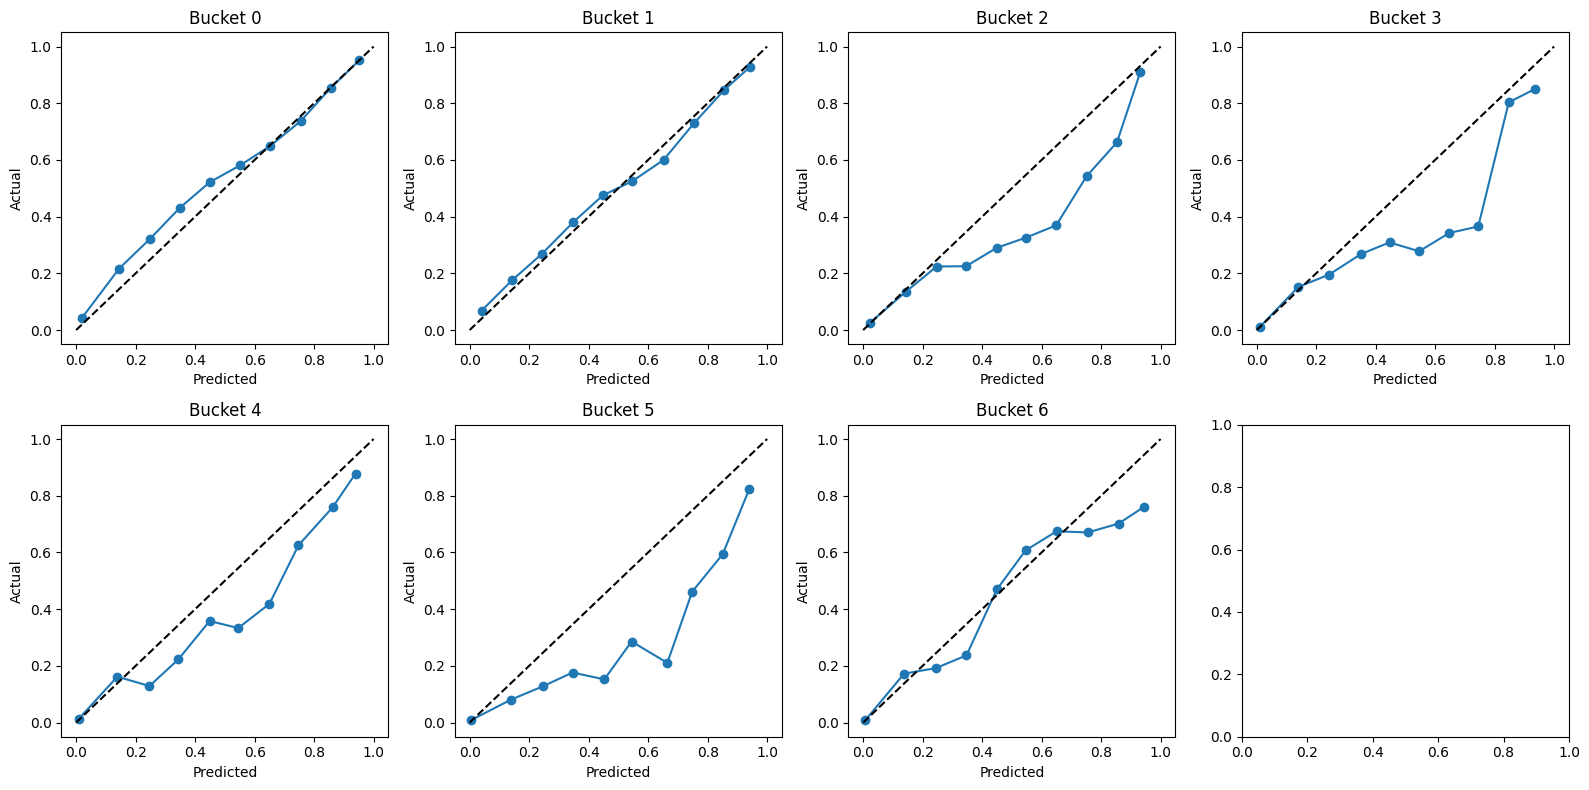

In [46]:
show_calibration_curves(xgb_probas, xgb_pipeline)

In [47]:
simulate_past_performance(xgb_pipeline)

Cutoff 2019-06-25 -> log_loss: 0.7939
Cutoff 2019-08-12 -> log_loss: 0.7514
Cutoff 2019-09-29 -> log_loss: 0.8493
Cutoff 2019-11-17 -> log_loss: 0.6716
Cutoff 2020-01-04 -> log_loss: 0.7259

Average: 0.7584 (std: 0.0603)


In [48]:
cutoff_date = big_df["reference_date"].quantile(0.8)
test_fold = np.where(big_df["reference_date"] <= cutoff_date, -1, 0)
ps = PredefinedSplit(test_fold)

X, y = preprocess(big_df)

param_distributions = {
    "classifier__n_estimators": [300, 500, 700],
    "classifier__max_depth": [4, 6, 8, 10, 12],
    "classifier__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "classifier__subsample": [0.6, 0.7, 0.8, 0.9],
    "classifier__colsample_bytree": [0.2, 0.3, 0.4, 0.5],
    "classifier__min_child_weight": randint(3, 15),
    "classifier__reg_alpha": [0, 0.01, 0.1, 0.5, 1.0],
    "classifier__reg_lambda": [0.5, 1.0, 2.0, 5.0],
    "classifier__gamma": [0, 0.1, 0.3, 0.5],
}

random_search = RandomizedSearchCV(
    xgb_pipeline,
    param_distributions,
    n_iter=50,
    cv=ps,
    scoring="neg_log_loss",
    n_jobs=-1,
    verbose=1,
    random_state=42,
)

random_search.fit(X, y)
print(f"Best log_loss: {-random_search.best_score_:.4f}")
print(f"Best params: {random_search.best_params_}")

Fitting 1 folds for each of 50 candidates, totalling 50 fits
Best log_loss: 0.6869
Best params: {'classifier__colsample_bytree': 0.5, 'classifier__gamma': 0, 'classifier__learning_rate': 0.01, 'classifier__max_depth': 10, 'classifier__min_child_weight': 13, 'classifier__n_estimators': 500, 'classifier__reg_alpha': 1.0, 'classifier__reg_lambda': 2.0, 'classifier__subsample': 0.9}


In [49]:
search_probas = random_search.predict_proba(X_test)
search_preds = random_search.predict(X_test)

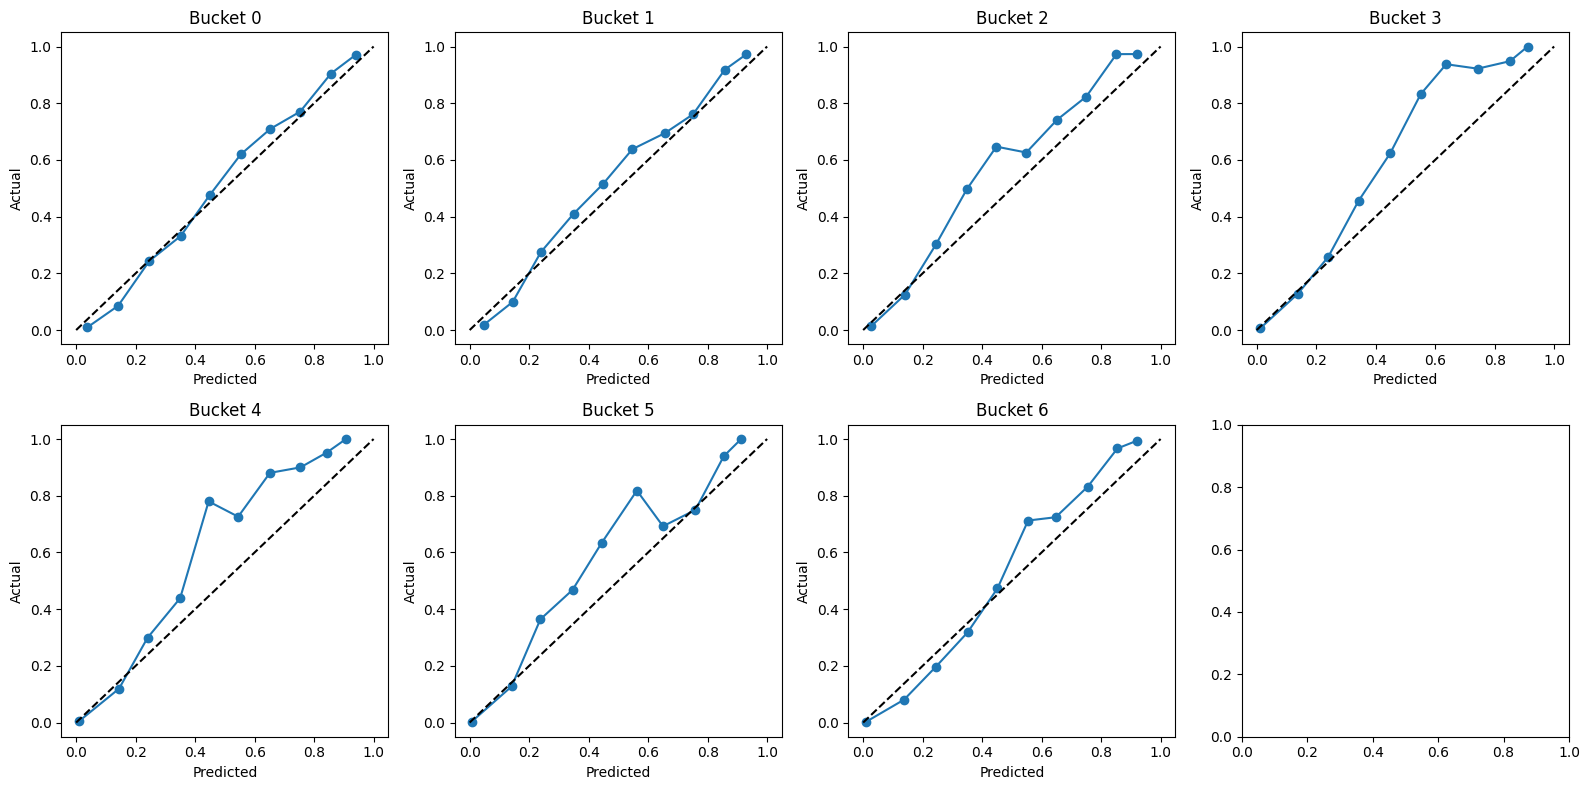

In [50]:
show_calibration_curves(search_probas, random_search)

In [51]:
evaluate_model(search_probas, search_preds)

Log loss: 0.5176
              precision    recall  f1-score   support

           0       0.86      0.94      0.90      9831
           1       0.83      0.81      0.82      7731
           2       0.77      0.57      0.66      2210
           3       0.72      0.60      0.65       798
           4       0.71      0.61      0.66       562
           5       0.72      0.52      0.60       316
           6       0.76      0.82      0.79       788

    accuracy                           0.83     22236
   macro avg       0.77      0.70      0.73     22236
weighted avg       0.83      0.83      0.82     22236

[[9264  461   44   18    7    3   34]
 [1188 6276  190   23   17    6   31]
 [ 187  635 1270   54   27    3   34]
 [  77   91   82  475   40    7   26]
 [  34   35   34   68  342   23   26]
 [  25   12   14   16   32  164   53]
 [  51   32   10    7   16   23  649]]


In [53]:
simulate_past_performance(random_search.best_estimator_)

Cutoff 2019-06-25 -> log_loss: 0.7349
Cutoff 2019-08-12 -> log_loss: 0.7092
Cutoff 2019-09-29 -> log_loss: 0.7854
Cutoff 2019-11-17 -> log_loss: 0.6160
Cutoff 2020-01-04 -> log_loss: 0.7049

Average: 0.7101 (std: 0.0551)
